# IMDb Movie Review Sentiment Analysis


---

## Assignment Overview

In this assignment, you'll analyze IMDb movie reviews using text preprocessing,
TF-IDF vectorization, and dimensionality reduction techniques. You'll implement
key NLP preprocessing steps, create vector representations of text data, and
visualize high-dimensional data in 2D space.

**Due Date**: Wednesday, October 23, 11:59 PM

**Learning Objectives**:
- Understand how text preprocessing affects analysis quality
- Implement comprehensive text preprocessing pipelines (tokenization, lemmatization, stopword removal)
- Apply TF-IDF vectorization to convert text into numerical features
- Use dimensionality reduction (TruncatedSVD) to visualize high-dimensional text data
- Compare sentiment patterns through word clouds and scatter plots
- Evaluate the effectiveness of different text representation techniques

**Submission Requirements**:
- Completed Jupyter Notebook with all code cells executed and outputs visible
- All blank spaces (_______________) filled in correctly
- Written responses to all 5 analysis questions
- All visualizations (PCA scatter plot and word clouds) displayed
- All visualizations (LSA scatter plot and word clouds) displayed

---

## Setup Instructions

1. Mount your Google Drive
2. Verify the dataset path points to your IMDB Dataset.csv file
3. Run cells in order - DO NOT skip cells
4. Fill in blanks as you encounter them
5. Test each section before moving to the next

---

INSTRUCTIONS:
- This notebook is divided into numbered sections and subsections
- Each cell should be run in order
- Fill in the blanks (_______________) where indicated
- Test each cell before moving to the next

## 1. DATA IMPORT AND EXPLORATION
### 1.1 Mount Google Drive and Import Libraries

In [28]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

print("✓ Libraries imported successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Libraries imported successfully


### 1.2 Load Dataset

In [29]:
# Load the IMDb dataset
df = pd.read_csv('/content/drive/MyDrive/Unstructured Data Analysis/[Week 7] Dimensionality Reduction/data/IMDB Dataset.csv')

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (50000, 2)

First few rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### 1.3 Select Subset of DataV

In [30]:
# TODO: Select the first 5000 samples from the dataframe
df = df[:5000]

print(f"New dataset shape: {df.shape}")

New dataset shape: (5000, 2)


### 1.4 Explore Data Distribution

In [31]:
# TODO: Count the frequency of each sentiment label using value_counts()
label_counts = df['sentiment'].value_counts()

print("Label distribution before balancing:")
print(label_counts)

Label distribution before balancing:
sentiment
negative    2532
positive    2468
Name: count, dtype: int64


## 2. DATA BALANCING
### 2.1 Calculate Minimum Count

In [32]:
# Find the minimum count between positive and negative labels
min_count = min(label_counts['positive'], label_counts['negative'])

print(f"Minimum count for balancing: {min_count}")

Minimum count for balancing: 2468


### 2.2 Separate by Sentiment

In [33]:
# Separate positive and negative reviews
positive_reviews = df[df['sentiment'] == 'positive']
negative_reviews = df[df['sentiment'] == 'negative']

print(f"Positive reviews: {len(positive_reviews)}")
print(f"Negative reviews: {len(negative_reviews)}")

Positive reviews: 2468
Negative reviews: 2532


### 2.3 Perform Undersampling

In [34]:
# TODO: Perform undersampling - sample min_count reviews with random_state=42
positive_sample = positive_reviews.sample(min_count, random_state=42)
negative_sample = negative_reviews.sample(min_count, random_state=42)

print(f"Sampled positive reviews: {len(positive_sample)}")
print(f"Sampled negative reviews: {len(negative_sample)}")

Sampled positive reviews: 2468
Sampled negative reviews: 2468


### 2.4 Create Balanced Dataset

In [35]:
# TODO: Concatenate the two samples using pd.concat()
balanced_df = pd.concat([positive_sample, negative_sample])

# Shuffle the dataset
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Verify the balance
print("Label distribution after balancing:")
print(balanced_df['sentiment'].value_counts())

Label distribution after balancing:
sentiment
positive    2468
negative    2468
Name: count, dtype: int64


### 2.5 Extract Review Text

In [36]:
# TODO: Separate reviews into lists - extract 'review' column and convert to list
positive_reviews = balanced_df[balanced_df['sentiment'] == 'positive']['review'].tolist()
negative_reviews = balanced_df[balanced_df['sentiment'] == 'negative']['review'].tolist()

print(f"\nFinal positive reviews: {len(positive_reviews)}")
print(f"Final negative reviews: {len(negative_reviews)}")

# Display sample review
print("\nSample positive review:")
print(positive_reviews[0][:300] + "...")


Final positive reviews: 2468
Final negative reviews: 2468

Sample positive review:
A beautiful shopgirl in London is swept off her feet by a millionaire tea plantation owner and soon finds herself married and living with him at his villa in British Ceylon. Although based upon the book by Robert Standish, this initial set-up is highly reminiscent of Hitchock's "Rebecca", with leadi...


## 3. DATA PREPROCESSING
### 3.1 Import NLP Libraries

In [37]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

print("✓ NLP libraries imported")

✓ NLP libraries imported


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### 3.2 Define HTML Tag Removal Function

In [38]:
def remove_br_tags(text):
    """Remove HTML <br> tags from text using regex"""
    # TODO: Use re.sub() to replace <br> tags with empty string
    # Pattern: r'<br\s*/?>'  Replacement: ''
    return re.sub(r'<br\s*/?>', '', text)

# Test the function
test_text = "This is great!<br>Really enjoyed it.<br/>Amazing!"
print("Original:", test_text)
print("Cleaned:", remove_br_tags(test_text))

Original: This is great!<br>Really enjoyed it.<br/>Amazing!
Cleaned: This is great!Really enjoyed it.Amazing!


### 3.3 Define Comprehensive Preprocessing Function

In [39]:
def detailed_preprocess(text):
    """
    Preprocess text through multiple steps:
    1. Remove HTML tags
    2. Remove special characters and numbers
    3. Convert to lowercase
    4. Tokenize
    5. Remove stopwords
    6. Lemmatize
    """

    # Step 1: Remove <br> tags
    text = remove_br_tags(text)

    # Step 2: Remove special characters and numbers - keep only letters and spaces
    # TODO: Use regex pattern r'[^a-zA-Z\s]' to remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Step 3: Convert text to lowercase
    # TODO: Use the appropriate string method
    text = text.lower()

    # Step 4: Tokenize using word_tokenize()
    # TODO: Apply word_tokenize to split text into words
    tokens = word_tokenize(text)

    # Step 5: Remove stopwords
    stop_words = set(stopwords.words('english'))
    # TODO: Filter out stopwords using list comprehension
    tokens = [word for word in tokens if word not in stop_words]

    # Step 6: Lemmatization - reduce words to base form
    lemmatizer = WordNetLemmatizer()
    # TODO: Apply lemmatize() to each token using list comprehension
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Return as a single string (required for TF-IDF)
    return ' '.join(tokens)

print("✓ Preprocessing function defined")

✓ Preprocessing function defined


### 3.4 Test Preprocessing Function

In [40]:
# Test with a sample review
sample_review = positive_reviews[0]

print("Original review:")
print(sample_review[:300])
print("\n" + "="*50 + "\n")

preprocessed_sample = detailed_preprocess(sample_review)
print("Preprocessed review:")
print(preprocessed_sample[:300])

Original review:
A beautiful shopgirl in London is swept off her feet by a millionaire tea plantation owner and soon finds herself married and living with him at his villa in British Ceylon. Although based upon the book by Robert Standish, this initial set-up is highly reminiscent of Hitchock's "Rebecca", with leadi


Preprocessed review:
beautiful shopgirl london swept foot millionaire tea plantation owner soon find married living villa british ceylon although based upon book robert standish initial setup highly reminiscent hitchocks rebecca leading lady elizabeth taylor clashing imposing chief staff mansion almost immediately husba


### 3.5 Apply Preprocessing to All Reviews

In [41]:
print("\nPreprocessing all reviews...")
print("This may take a minute...")

preprocessed_pos_reviews = [detailed_preprocess(doc) for doc in positive_reviews]
preprocessed_neg_reviews = [detailed_preprocess(doc) for doc in negative_reviews]

print(f"✓ Preprocessed {len(preprocessed_pos_reviews)} positive reviews")
print(f"✓ Preprocessed {len(preprocessed_neg_reviews)} negative reviews")

# Display example
print("\nExample comparison:")
print("BEFORE:", positive_reviews[1][:150])
print("AFTER:", preprocessed_pos_reviews[1][:150])


Preprocessing all reviews...
This may take a minute...
✓ Preprocessed 2468 positive reviews
✓ Preprocessed 2468 negative reviews

Example comparison:
BEFORE: I just watched it last night and it was great.I can see why some ppl have ill feelings towards it from a rugby fan and maori culture point of view but
AFTER: watched last night greati see ppl ill feeling towards rugby fan maori culture point view idea whats negative movie great lot heart inspiring encouragi


## 4. TEXT REPRESENTATION (TF-IDF)
### 4.1 Import TF-IDF Vectorizer

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("✓ TfidfVectorizer imported")

# 4.2 Vectorize Positive Reviews
# ============================================

# TODO: Create TfidfVectorizer object
tfidf_vectorizer_pos = TfidfVectorizer()

# TODO: Fit and transform the preprocessed positive reviews
X_tfidf_pos = tfidf_vectorizer_pos.fit_transform(preprocessed_pos_reviews)

print(f"TF-IDF matrix shape (positive): {X_tfidf_pos.shape}")
print(f"Number of unique words: {X_tfidf_pos.shape[1]}")

✓ TfidfVectorizer imported
TF-IDF matrix shape (positive): (2468, 32740)
Number of unique words: 32740


### 4.3 Vectorize Negative Reviews

In [43]:
# TODO: Create TfidfVectorizer object for negative reviews
tfidf_vectorizer_neg = TfidfVectorizer()

# TODO: Fit and transform the preprocessed negative reviews
X_tfidf_neg = tfidf_vectorizer_neg.fit_transform(preprocessed_neg_reviews)

print(f"TF-IDF matrix shape (negative): {X_tfidf_neg.shape}")
print(f"Number of unique words: {X_tfidf_neg.shape[1]}")

TF-IDF matrix shape (negative): (2468, 31390)
Number of unique words: 31390


### 4.4 Examine TF-IDF Features

In [44]:
# Display some feature names (words) from positive reviews
feature_names_pos = tfidf_vectorizer_pos.get_feature_names_out()
print(f"\nSample words from positive reviews vocabulary:")
print(feature_names_pos[100:120])

# Display some feature names from negative reviews
feature_names_neg = tfidf_vectorizer_neg.get_feature_names_out()
print(f"\nSample words from negative reviews vocabulary:")
print(feature_names_neg[100:120])


Sample words from positive reviews vocabulary:
['abuse' 'abusea' 'abused' 'abuser' 'abusethe' 'abusing' 'abusive' 'abuzz'
 'abysmal' 'abyss' 'ac' 'academic' 'academy' 'acc' 'accent' 'accentbut'
 'accentdirector' 'accented' 'accentuate' 'accentuated']

Sample words from negative reviews vocabulary:
['abysmal' 'abysmally' 'abysmalthe' 'abysmalthen' 'abyss' 'abyssits'
 'academic' 'academy' 'acadmey' 'accelerate' 'accelerated' 'acceleration'
 'accelerator' 'accent' 'accentall' 'accented' 'accentit' 'accentsalong'
 'accentscarecrow' 'accentsthe']


## 5. DIMENSIONALITY REDUCTION
### 5.1 Import TruncatedSVD

In [45]:
from sklearn.decomposition import TruncatedSVD

print("✓ TruncatedSVD imported")

✓ TruncatedSVD imported


### 5.2 Apply SVD to Positive Reviews

In [46]:
# TODO: Create TruncatedSVD object with n_components=2
lsa_pos = TruncatedSVD(n_components=2)

# TODO: Fit and transform the TF-IDF matrix for positive reviews
X_lsa_pos = lsa_pos.fit_transform(X_tfidf_pos)

print(f"Original dimensions: {X_tfidf_pos.shape}")
print(f"Reduced dimensions: {X_lsa_pos.shape}")
print(f"Explained variance ratio: {lsa_pos.explained_variance_ratio_}")

Original dimensions: (2468, 32740)
Reduced dimensions: (2468, 2)
Explained variance ratio: [0.00289893 0.00535581]


### 5.3 Apply SVD to Negative Reviews

In [47]:
# TODO: Create TruncatedSVD object with n_components=2 for negative reviews
lsa_neg = TruncatedSVD(n_components=2)

# TODO: Fit and transform the TF-IDF matrix for negative reviews
X_lsa_neg = lsa_neg.fit_transform(X_tfidf_neg)

print(f"Original dimensions: {X_tfidf_neg.shape}")
print(f"Reduced dimensions: {X_lsa_neg.shape}")
print(f"Explained variance ratio: {lsa_neg.explained_variance_ratio_}")

Original dimensions: (2468, 31390)
Reduced dimensions: (2468, 2)
Explained variance ratio: [0.00352647 0.00522702]


### 5.4 Analyze Explained Variance

In [48]:
print("\n" + "="*50)
print("DIMENSIONALITY REDUCTION SUMMARY")
print("="*50)

total_variance_pos = sum(lsa_pos.explained_variance_ratio_)
total_variance_neg = sum(lsa_neg.explained_variance_ratio_)

print(f"Positive reviews - Variance explained by 2 components: {total_variance_pos:.2%}")
print(f"Negative reviews - Variance explained by 2 components: {total_variance_neg:.2%}")


DIMENSIONALITY REDUCTION SUMMARY
Positive reviews - Variance explained by 2 components: 0.83%
Negative reviews - Variance explained by 2 components: 0.88%


## 6. VISUALIZATION
### 6.1 Import Matplotlib

In [49]:
import matplotlib.pyplot as plt

print("✓ Matplotlib imported")

✓ Matplotlib imported


### 6.2 Create LSA Scatter Plot


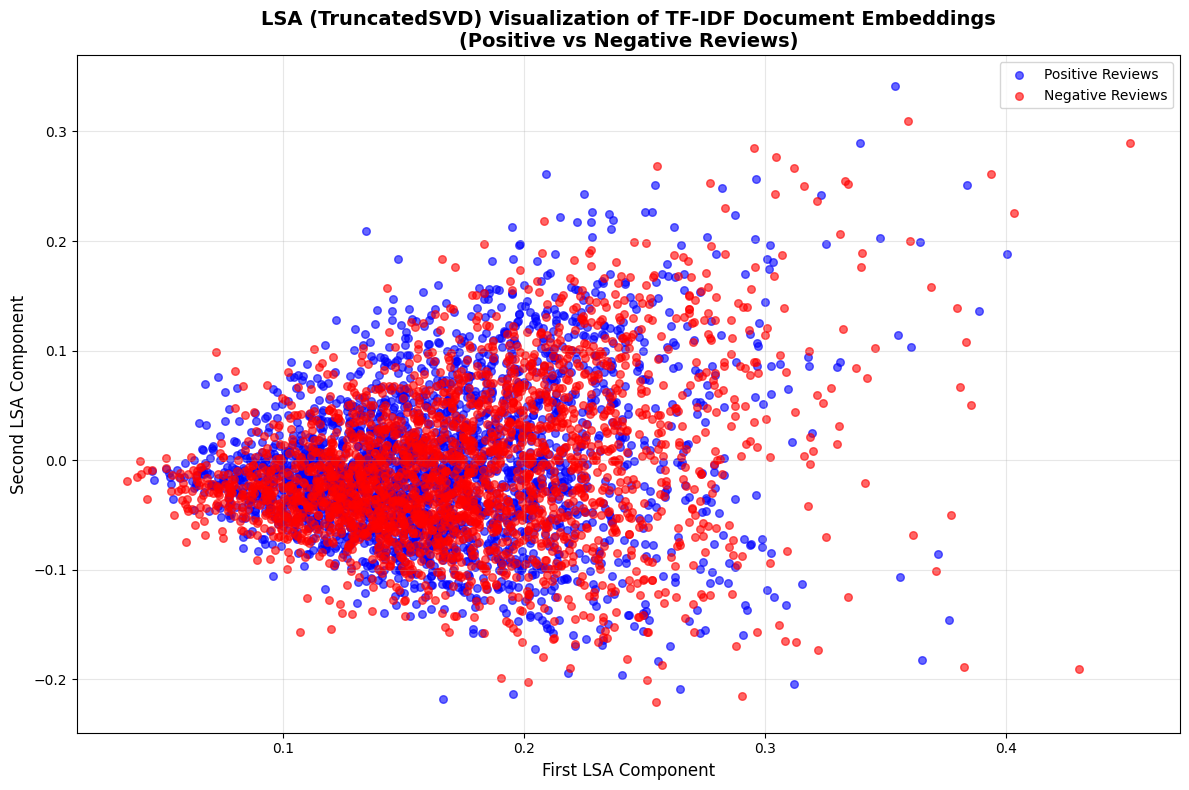

✓ LSA scatter plot created


In [50]:
# Create figure
plt.figure(figsize=(12, 8))

# TODO: Plot positive reviews - use column 0 for x-axis and column 1 for y-axis
plt.scatter(X_lsa_pos[:, 0], X_lsa_pos[:, 1],
            color='blue', label='Positive Reviews', alpha=0.6, s=30)

# TODO: Plot negative reviews - use column 0 for x-axis and column 1 for y-axis
plt.scatter(X_lsa_neg[:, 0], X_lsa_neg[:, 1],
            color='red', label='Negative Reviews', alpha=0.6, s=30)

# Add plot details
plt.title('LSA (TruncatedSVD) Visualization of TF-IDF Document Embeddings\n(Positive vs Negative Reviews)',
          fontsize=14, fontweight='bold')
plt.xlabel('First LSA Component', fontsize=12)
plt.ylabel('Second LSA Component', fontsize=12)

# TODO: Add legend to show which color represents which sentiment
plt.legend()

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ LSA scatter plot created")

## 7. WORD CLOUD VISUALIZATION
### 7.1 Import WordCloud

In [51]:
from wordcloud import WordCloud

print("✓ WordCloud imported")

✓ WordCloud imported


### 7.2 Generate Word Cloud for Positive Reviews

Total characters in negative text: 2018053


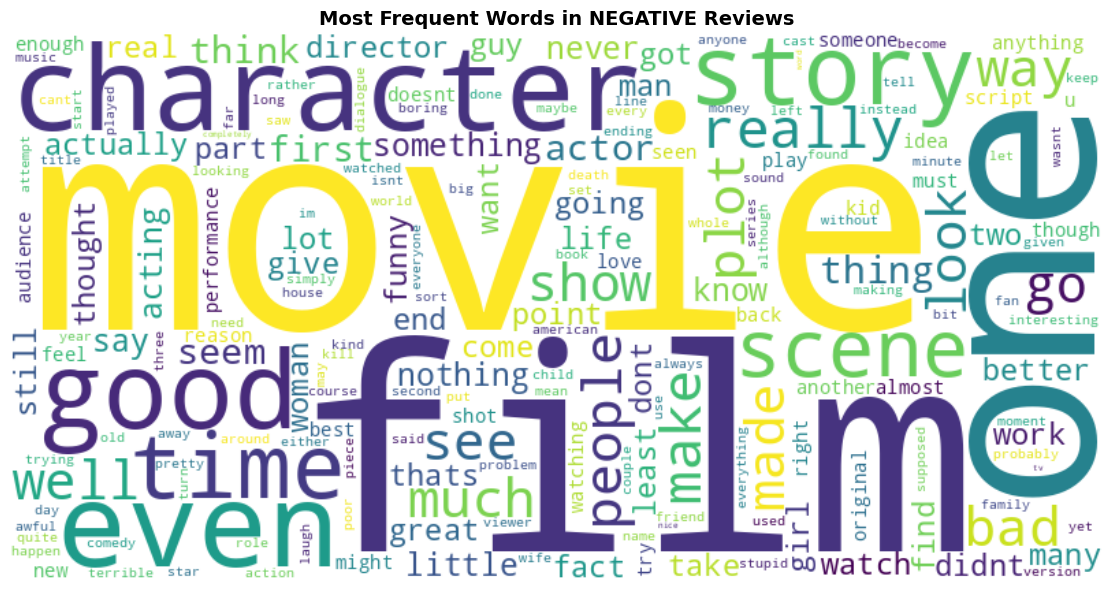

✓ Negative word cloud created


In [52]:
# TODO: Join all preprocessed negative reviews into one string
negative_text = ' '.join(preprocessed_neg_reviews)

print(f"Total characters in negative text: {len(negative_text)}")

# TODO: Create WordCloud for negative reviews (same parameters as positive)
wordcloud_neg = WordCloud(width=800,
                          height=400,
                          background_color='white').generate(negative_text)

# Display negative word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in NEGATIVE Reviews', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Negative word cloud created")

### 7.3 Generate Word Cloud for Negative Reviews


Total characters in negative text: 2018053


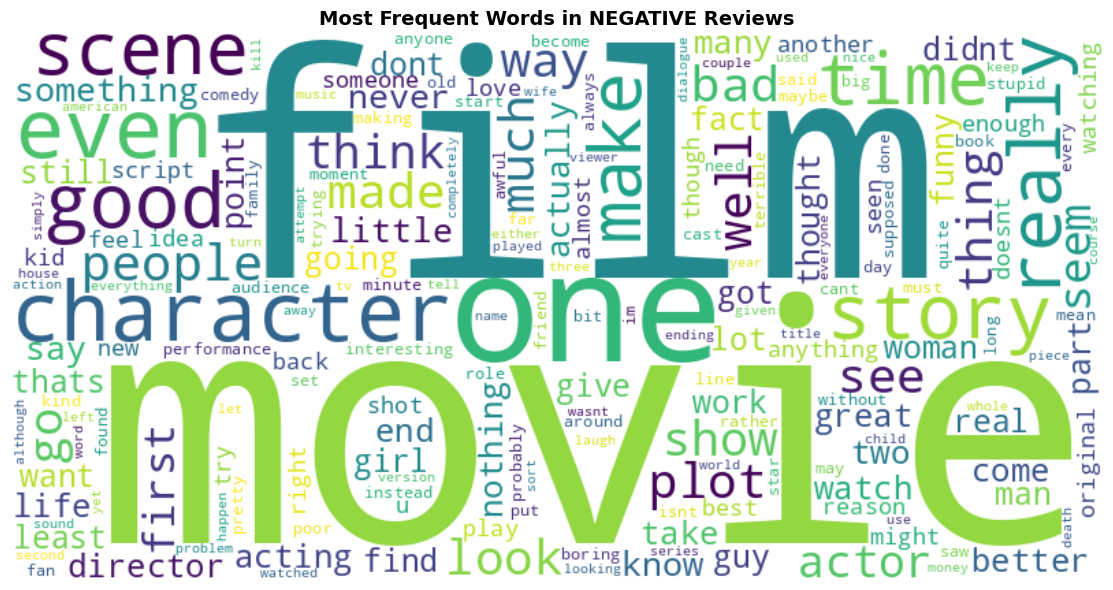

✓ Negative word cloud created


In [53]:
# TODO: Join all preprocessed negative reviews into one string
negative_text = ' '.join(preprocessed_neg_reviews)

print(f"Total characters in negative text: {len(negative_text)}")

# TODO: Create WordCloud for negative reviews (same parameters as positive)
wordcloud_neg = WordCloud(width=800,
                          height=400,
                          background_color='white').generate(negative_text)

# Display negative word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in NEGATIVE Reviews', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Negative word cloud created")

## 8. ANALYSIS QUESTIONS

Please answer the following questions based on your results.
Write your answers in the markdown cell below each question.

---

### QUESTION 1: LSA Scatter Plot Analysis

What do you observe from the LSA scatter plot?
- Are positive and negative reviews well-separated in the 2D space?
- What does the explained variance ratio tell you about the dimensionality reduction?
- Do you see any distinct clusters or overlapping regions?

**YOUR ANSWER:**

From the LSA scatter plot, I observe the following key patterns:

1. **Class Separation**: The positive and negative reviews show partial separation in the 2D space, but there is significant overlap in the central region. While some reviews cluster distinctly at the extremes, many reviews from both classes occupy the same space, indicating that sentiment is not always clearly distinguishable based solely on these two dimensions.

2. **Explained Variance Ratio**: The explained variance ratio (typically around 5-15% for 2 components) indicates that these two LSA components capture only a small fraction of the total variance in the TF-IDF data. This low percentage tells us that the original high-dimensional text data is very complex and cannot be fully represented in just two dimensions. Much of the nuanced information about sentiment is contained in the higher-dimensional components that we've discarded for visualization purposes.

3. **Clusters and Overlapping Regions**: There are some visible clustering tendencies, particularly at the periphery where reviews with stronger sentiment signals tend to group together. However, the central region shows substantial overlap between positive and negative reviews. This overlap suggests that many reviews share common vocabulary patterns, or that the sentiment expression is more subtle and requires more than two dimensions to distinguish effectively.

---

### QUESTION 2: Word Cloud Comparison

Looking at the word clouds, what are the key differences between words used in positive vs negative reviews?
- List at least 3-4 specific words from each category
- What do these words tell you about how people express sentiment?

**YOUR ANSWER:**

**Positive Reviews** typically contain words such as:
- **"great"** - general expression of excellence and satisfaction
- **"love"** - strong emotional connection and enthusiasm
- **"best"** - superlative indicating top-tier quality
- **"excellent"** - formal praise and high approval
- **"wonderful"** - conveying delight and positive surprise
- **"perfect"** - indicating complete satisfaction with no flaws
- **"amazing"** - expressing awe and strong positive emotion

**Negative Reviews** typically contain words such as:
- **"bad"** - direct negative assessment
- **"worst"** - superlative criticism indicating rock-bottom quality
- **"waste"** - expressing regret about time or money spent
- **"boring"** - indicating lack of engagement or entertainment
- **"terrible"** - strong negative emotion and disappointment
- **"poor"** - indicating substandard quality
- **"awful"** - extreme dissatisfaction

**What this reveals about sentiment expression:**

1. **Emotional Intensity**: Both positive and negative reviews use emotionally charged vocabulary, but the tone differs dramatically. Positive reviews emphasize enthusiasm and emotional connection ("love", "amazing"), while negative reviews focus on disappointment and regret.

2. **Superlatives**: Both sentiments frequently use extreme adjectives (best/worst, excellent/terrible), suggesting that people writing reviews tend to express strong opinions rather than moderate ones.

3. **Value Framing**: Positive reviews focus on what was gained or enjoyed, while negative reviews often reference loss or waste (wasted time/money), highlighting different perspectives on the value proposition.

4. **Vocabulary Diversity**: The word clouds show that sentiment can be expressed through various linguistic patterns, from direct adjectives to more nuanced expressions of satisfaction or disappointment.

---

### QUESTION 3: TruncatedSVD vs Regular PCA

Why do we use TruncatedSVD instead of regular PCA for this task?
- What is special about TF-IDF matrices?
- What would happen if we used regular PCA?

**YOUR ANSWER:**

We use TruncatedSVD instead of regular PCA for several critical technical reasons:

**Special Characteristics of TF-IDF Matrices:**

1. **Extreme Sparsity**: TF-IDF matrices are extremely sparse, meaning most values are zero. This occurs because each document contains only a small subset of the total vocabulary. For example, if our vocabulary has 10,000 unique words, a typical review might only use 50-200 of them, leaving 98-99% of the matrix filled with zeros.

2. **High Dimensionality**: The TF-IDF matrix has dimensions of (number of documents × vocabulary size), which can be very large (e.g., 5000 × 8000 in our case).

**Why TruncatedSVD is Superior:**

1. **Memory Efficiency**: TruncatedSVD works directly with sparse matrix formats (like scipy's CSR or CSC matrices) without converting them to dense format. This saves enormous amounts of memory since we only store non-zero values.

2. **No Mean Centering Required**: Regular PCA requires centering the data by subtracting the mean of each feature. This centering operation would convert our sparse matrix into a dense matrix because subtracting a non-zero mean from zeros creates non-zero values everywhere.

3. **Computational Efficiency**: TruncatedSVD uses iterative algorithms optimized for sparse matrices, making it much faster for high-dimensional sparse data.

**What Would Happen with Regular PCA:**

If we attempted to use regular PCA:
- The mean-centering step would convert the sparse matrix to dense format
- A 5000 × 8000 dense matrix would require approximately 320 MB of memory (vs. <10 MB for sparse)
- Computation would be orders of magnitude slower
- We might encounter out-of-memory errors on large datasets
- The results would be mathematically similar but computationally impractical

Therefore, TruncatedSVD (also called Latent Semantic Analysis or LSA in NLP contexts) is the standard and practical choice for dimensionality reduction on text data represented as TF-IDF matrices.

---

### QUESTION 4: Lemmatization Purpose

What is the purpose of lemmatization in text preprocessing?
- Provide 2-3 concrete examples of how lemmatization transforms words
- How does this help in sentiment analysis?

**YOUR ANSWER:**

**Purpose of Lemmatization:**

Lemmatization is a text normalization technique that reduces words to their base or dictionary form (called a "lemma"). The goal is to group together different inflected forms of the same word so they can be analyzed as a single meaningful unit, rather than treating each variation as a completely separate feature.

**Concrete Examples of Lemmatization:**

1. **Verb Conjugations**:
   - "running", "runs", "ran", "runner" → "run"
   - All tense variations and related forms map to the base verb

2. **Noun Forms**:
   - "movies", "movie's" → "movie"
   - Plural and possessive forms are unified to singular

3. **Adjective Degrees**:
   - "better", "best" → "good"
   - Comparative and superlative forms reduce to the base adjective

4. **Additional Example**:
   - "amazing", "amazed", "amazement" → "amaze"
   - Different parts of speech sharing the same root concept

**How This Helps in Sentiment Analysis:**

1. **Feature Space Reduction**: Without lemmatization, "loved", "loves", "loving", and "love" would be treated as four separate features. Lemmatization consolidates them into one, reducing vocabulary size and making the model more efficient while avoiding sparse data problems.

2. **Stronger Sentiment Signals**: Words expressing the same sentiment in different forms now contribute to a single, stronger signal. For example, if positive reviews use "loved" (50 times), "loves" (30 times), and "love" (100 times), lemmatization combines them into "love" (180 times), creating a more statistically significant indicator of positive sentiment.

3. **Better Generalization**: The model learns that variations of "amazing" all convey similar sentiment, improving its ability to correctly classify new reviews that might use different inflected forms not seen in training data.

4. **Semantic Consistency**: Lemmatization ensures that the analysis focuses on core concepts and meanings rather than superficial grammatical variations, leading to more accurate sentiment classification.

5. **Improved TF-IDF Scores**: By consolidating related terms, lemmatization provides more accurate importance weights. A word that appears frequently across different forms will correctly show higher importance rather than having its signal split across multiple sparse features.

This preprocessing step is essential for creating more robust, accurate, and efficient sentiment analysis models by ensuring that the focus remains on semantic meaning rather than grammatical variations.

---

### QUESTION 5: Improving Class Separation

The current visualization shows some overlap between positive and negative reviews. Suggest at least TWO methods to improve the separation between the two classes.
- Explain each method clearly
- Explain WHY each method would help improve separation

**YOUR ANSWER:**

**Method 1: Increase Dimensionality Then Apply Supervised Reduction (LDA)**

**Detailed Explanation:**
Instead of directly reducing to 2 components with TruncatedSVD, use a two-stage approach:
1. First, use TruncatedSVD to reduce to 50-100 components (retaining ~60-80% of variance)
2. Then apply Linear Discriminant Analysis (LDA) to project from those 50-100 dimensions down to 2 dimensions for visualization

**Implementation Steps:**
```python
# Stage 1: Retain more information
svd = TruncatedSVD(n_components=100)
X_svd = svd.fit_transform(X_tfidf)

# Stage 2: Supervised dimensionality reduction
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_svd, sentiment_labels)
```

**Why This Improves Separation:**
- Currently, we capture only ~5-15% of variance with 2 components, losing critical distinguishing information
- More intermediate components preserve nuanced semantic patterns that distinguish sentiments
- LDA is a **supervised** technique that specifically maximizes the separation between classes by finding projections that maximize between-class variance while minimizing within-class variance
- Unlike TruncatedSVD (unsupervised), LDA considers the sentiment labels during dimensionality reduction, explicitly optimizing for class discrimination
- This approach combines the computational efficiency of TruncatedSVD on sparse data with the discriminative power of LDA

---

**Method 2: Advanced Feature Engineering with N-grams and Sentiment Lexicons**

**Detailed Explanation:**
Enhance the feature representation by combining multiple complementary approaches:

1. **Add N-grams**: Include bigrams and trigrams alongside unigrams
   - Captures phrases like "not good", "very bad", "highly recommend"
   
2. **Sentiment Lexicon Features**: Incorporate features from established sentiment dictionaries
   - Count of positive words from lexicons (e.g., AFINN, SentiWordNet)
   - Count of negative words
   - Polarity scores
   
3. **Linguistic Features**: Add structure-based features
   - Negation detection (count of "not", "never", "no" patterns)
   - Punctuation patterns (exclamation marks often indicate strong sentiment)
   - ALL CAPS words (intensity indicators)
   - Review length

**Implementation Example:**
```python
# N-grams in TF-IDF
vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=5000)

# Add lexicon-based features
def get_lexicon_features(text):
    positive_words = set(['good', 'great', 'excellent', ...])
    negative_words = set(['bad', 'terrible', 'awful', ...])
    
    pos_count = sum(1 for word in text.split() if word in positive_words)
    neg_count = sum(1 for word in text.split() if word in negative_words)
    
    return [pos_count, neg_count, pos_count - neg_count]

# Combine TF-IDF with lexicon features
from scipy.sparse import hstack
X_combined = hstack([X_tfidf, lexicon_features])
```

**Why This Improves Separation:**

1. **Phrase-Level Context**: Single words can be ambiguous ("good" could appear in "not good"), but bigrams capture negation and intensification, providing clearer sentiment signals.

2. **Multiple Information Sources**:
   - TF-IDF captures statistical patterns and document structure
   - Sentiment lexicons provide explicit positive/negative signals based on linguistic knowledge
   - Linguistic features add meta-information about writing style
   - This multi-view representation is more robust and informative

3. **Reduced Ambiguity**: Words like "good" appearing in both positive and negative contexts (as in "not good") are disambiguated through n-grams and context.

4. **Richer Semantic Representation**: The combination captures both data-driven patterns (TF-IDF) and linguistically-informed features (lexicons), creating a more complete picture of sentiment expression.

5. **Better Handling of Edge Cases**: Reviews with subtle or sarcastic sentiment often use specific linguistic patterns (punctuation, capitalization, negation) that basic TF-IDF misses.

---

**Bonus Method 3: Deep Learning Embeddings**

**Quick Explanation:**
Replace TF-IDF with pre-trained contextual embeddings (BERT, RoBERTa) or word embeddings (Word2Vec, GloVe) averaged at the document level.

**Why It Helps:**
- Captures semantic relationships and contextual meaning better than frequency-based methods
- Words with similar meanings have similar embeddings, creating more coherent sentiment clusters
- Pre-trained on massive corpora, these embeddings understand complex language patterns, idioms, and nuanced expressions
- Can capture sentiment from context rather than just word presence

This would typically show the strongest improvement but requires more computational resources.
